# Exploring the Multimodal Zarr Stores

This notebook shows how to open and navigate the `{mouse_id}_multimodal_data.zarr` stores produced by `Save_multimodal_data.ipynb`.

**Zarr hierarchy overview:**
```
{mouse_id}_multimodal_data.zarr/
├── unique_id/
├── morphology/mask_properties/
├── transcriptomics/{cell_type, cellxgene}/
└── ophys/drifting_gratings/{session_1,2,3}/
    ├── stim_aligned_dff/{GratingStim, Catch, GreyScreen}/
    ├── dff_avg/
    ├── dff_baseline/
    ├── tuning_properties/
    └── glm/
```

In [8]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import zarr
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('talk')
sns.set_style('whitegrid')

from functions.data_loading import zarr_to_df

from pathlib import Path

## 1. Open a Zarr Store and Browse Its Structure

In [5]:
SCRATCH_DIR = Path('../scratch')
MULTIMODAL = SCRATCH_DIR / 'multimodal_data'

MOUSE_IDS = ['778174', '786297', '797371']

# Pick one mouse to explore
mouse_id = MOUSE_IDS[0]
zarr_path = MULTIMODAL / f'{mouse_id}_multimodal_data.zarr'

z = zarr.open(str(zarr_path), mode='r')
print(f'Zarr store: {zarr_path}')
print(f'Top-level groups: {list(z.keys())}')

Zarr store: ../scratch/multimodal_data/778174_multimodal_data.zarr
Top-level groups: ['morphology', 'ophys', 'transcriptomics', 'unique_id']


In [6]:
# Print the full tree (max depth 3 to keep it readable)
print(z.tree(level=3))

/
 ├── morphology
 │   └── mask_properties
 │       ├── angle_deg_xy (614,) float64
 │       ├── centroid_x_um (614,) float64
 │       ├── centroid_y_um (614,) float64
 │       ├── centroid_z_um (614,) float64
 │       ├── n_voxels (614,) int64
 │       ├── size_pc1_um (614,) float64
 │       ├── size_pc2_um (614,) float64
 │       ├── size_pc3_um (614,) float64
 │       ├── size_x_um (614,) float64
 │       ├── size_y_um (614,) float64
 │       └── size_z_um (614,) float64
 ├── ophys
 │   └── drifting_gratings
 │       ├── session_1
 │       ├── session_2
 │       └── session_3
 ├── transcriptomics
 │   ├── cell_type
 │   │   ├── class_bootstrapping_probability (614,) float64
 │   │   ├── class_label (614,) object
 │   │   ├── class_name (614,) object
 │   │   ├── cluster_alias (614,) float64
 │   │   ├── cluster_bootstrapping_probability (614,) float64
 │   │   ├── cluster_label (614,) object
 │   │   ├── cluster_name (614,) object
 │   │   ├── subclass_bootstrapping_probability (614

## 2. Unique IDs — The Shared Cell Index

In [7]:
unique_ids = z['unique_id'][:].astype(str)
print(f'Number of cells: {len(unique_ids)}')
print(f'First 5 IDs: {unique_ids[:5]}')

Number of cells: 614
First 5 IDs: ['778174_4_470' '778174_4_497' '778174_4_513' '778174_4_545'
 '778174_5_516']


## 3. Transcriptomics — Cell-Type Labels

In [16]:
ct = z['transcriptomics/cell_type']
print('Cell-type arrays:', list(ct.keys()))

# Build a cell-type DataFrame
ct_df = zarr_to_df(ct)
ct_df['unique_id'] = unique_ids
ct_df.set_index('unique_id', inplace=True)
ct_df.head()

Cell-type arrays: ['class_bootstrapping_probability', 'class_label', 'class_name', 'cluster_alias', 'cluster_bootstrapping_probability', 'cluster_label', 'cluster_name', 'subclass_bootstrapping_probability', 'subclass_label', 'subclass_name', 'supertype_bootstrapping_probability', 'supertype_label', 'supertype_name']


,class_bootstrapping_probability,class_label,class_name,cluster_alias,cluster_bootstrapping_probability,cluster_label,cluster_name,subclass_bootstrapping_probability,subclass_label,subclass_name,supertype_bootstrapping_probability,supertype_label,supertype_name
unique_id,,,,,,,,,,,,,
778174_4_470,0.69,CS20230722_CLAS_01,01 IT-ET Glut,200.0,0.49,CS20230722_CLUS_0102,0102 L4/5 IT CTX Glut_6,0.65,CS20230722_SUBC_006,006 L4/5 IT CTX Glut,0.40,CS20230722_SUPT_0028,0028 L4/5 IT CTX Glut_6
778174_4_497,0.51,CS20230722_CLAS_01,01 IT-ET Glut,235.0,0.99,CS20230722_CLUS_0118,0118 L2/3 IT CTX Glut_4,0.97,CS20230722_SUBC_007,007 L2/3 IT CTX Glut,0.58,CS20230722_SUPT_0032,0032 L2/3 IT CTX Glut_4
778174_4_513,0.98,CS20230722_CLAS_06,06 CTX-CGE GABA,626.0,0.51,CS20230722_CLUS_0645,0645 Vip Gaba_6,0.91,CS20230722_SUBC_046,046 Vip Gaba,0.83,CS20230722_SUPT_0178,0178 Vip Gaba_6
778174_4_545,1.00,CS20230722_CLAS_01,01 IT-ET Glut,232.0,1.00,CS20230722_CLUS_0109,0109 L2/3 IT CTX Glut_2,1.00,CS20230722_SUBC_007,007 L2/3 IT CTX Glut,0.95,CS20230722_SUPT_0030,0030 L2/3 IT CTX Glut_2
778174_5_516,1.00,CS20230722_CLAS_01,01 IT-ET Glut,233.0,0.75,CS20230722_CLUS_0110,0110 L2/3 IT CTX Glut_2,0.99,CS20230722_SUBC_007,007 L2/3 IT CTX Glut,0.72,CS20230722_SUPT_0030,0030 L2/3 IT CTX Glut_2


In [10]:
# Subclass distribution
print(ct_df['subclass_name'].value_counts())

subclass_name
006 L4/5 IT CTX Glut    313
007 L2/3 IT CTX Glut    245
052 Pvalb Gaba           26
046 Vip Gaba             20
053 Sst Gaba              6
049 Lamp5 Gaba            4
Name: count, dtype: int64


## 4. Transcriptomics — Gene Expression

In [11]:
cxg = z['transcriptomics/cellxgene']
cxg_df = zarr_to_df(cxg)
cxg_df['unique_id'] = unique_ids
cxg_df.set_index('unique_id', inplace=True)
gene_names = cxg_df.columns.tolist()
print(f'Number of genes: {len(gene_names)}')
print(f'First 10 genes: {gene_names[:10]}')

# Load a single gene
pvalb_expr = cxg_df['Pvalb'].values
print(f'\nPvalb expression — shape: {pvalb_expr.shape}, range: [{pvalb_expr.min():.2f}, {pvalb_expr.max():.2f}]')

Number of genes: 299
First 10 genes: ['2010300C02Rik', 'Acsbg1', 'Acta2', 'Acvrl1', 'Adamts2', 'Adamtsl1', 'Adcyap1', 'Adgrl4', 'Aldh1a2', 'Angpt1']

Pvalb expression — shape: (614,), range: [0.00, 91.00]


In [15]:
cxg_df.head()

,2010300C02Rik,Acsbg1,Acta2,Acvrl1,Adamts2,Adamtsl1,Adcyap1,Adgrl4,Aldh1a2,Angpt1,...,Zfp366,Zfp536,Zfpm2,dTomato,mKate2,mRuby3,mScarlet,pAAV.CMV.LacZ.bGH,pAAV.CMV.ffLuciferase.SV40,pHaloTag-EGFP
unique_id,,,,,,,,,,,,,,,,,,,,,
778174_4_470,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778174_4_497,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778174_4_513,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778174_4_545,8.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
778174_5_516,8.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Morphology — Mask Properties

In [17]:
morph = z['morphology/mask_properties']
print('Morphology arrays:', list(morph.keys()))

morph_df = zarr_to_df(morph)
morph_df['unique_id'] = unique_ids
morph_df.set_index('unique_id', inplace=True)
morph_df.head()

Morphology arrays: ['angle_deg_xy', 'centroid_x_um', 'centroid_y_um', 'centroid_z_um', 'n_voxels', 'size_pc1_um', 'size_pc2_um', 'size_pc3_um', 'size_x_um', 'size_y_um', 'size_z_um']


,angle_deg_xy,centroid_x_um,centroid_y_um,centroid_z_um,n_voxels,size_pc1_um,size_pc2_um,size_pc3_um,size_x_um,size_y_um,size_z_um
unique_id,,,,,,,,,,,
778174_4_470,-14.332495,213.761428,211.510877,100.834389,3001,38.477145,24.122580,14.811789,20.507812,15.039062,35.0
778174_4_497,-10.457120,227.159812,226.548598,99.059412,1700,21.761379,16.782769,14.841572,13.671875,16.406250,21.0
778174_4_513,60.504626,231.043474,274.759034,100.779145,1707,27.533734,18.135643,14.231660,15.039062,16.406250,24.0
778174_4_545,-119.208380,181.393581,272.363809,102.000772,1295,21.760312,16.423669,12.438542,10.937500,15.039062,20.0
778174_5_516,148.059934,346.010614,373.601151,101.651914,2011,23.951486,19.654741,15.150548,17.773438,15.039062,21.0


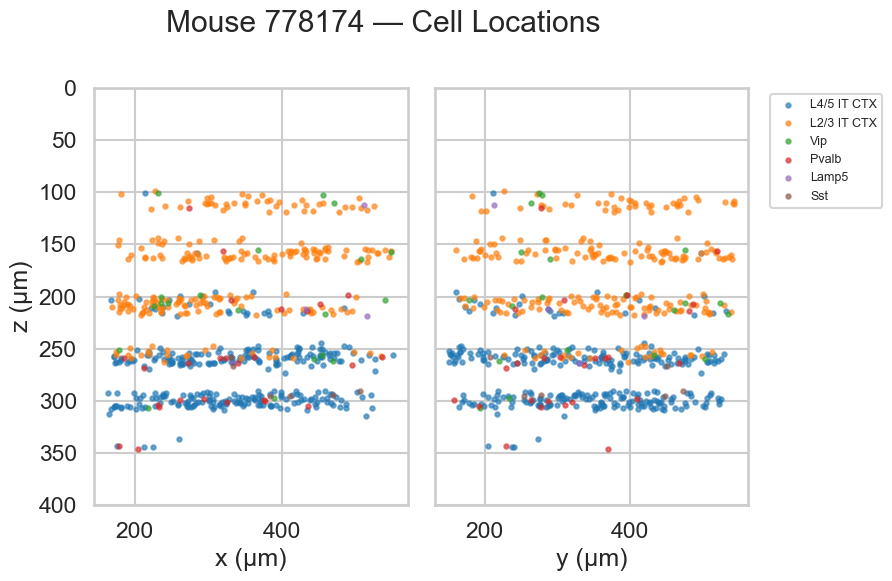

In [29]:
# Spatial layout coloured by subclass
fig, axs = plt.subplots(1, 2, figsize=(8, 6))
morph_ct_df = morph_df.join(ct_df)
for sc in morph_ct_df['subclass_name'].unique():
        mask = morph_ct_df['subclass_name'] == sc
        ax = axs[0]
        ax.scatter(morph_ct_df.loc[mask, 'centroid_x_um'], morph_ct_df.loc[mask, 'centroid_z_um'],
                s=10, alpha=0.6, label=sc.split()[-2])
        ax.set_xlabel('x (µm)'); ax.set_ylabel('z (µm)')
        ax.set_ylim(400, 0)

        ax = axs[1]
        ax.scatter(morph_ct_df.loc[mask, 'centroid_y_um'], morph_ct_df.loc[mask, 'centroid_z_um'],
                s=10, alpha=0.6, label=' '.join(sc.split()[1:-1]))
        ax.set_xlabel('y (µm)')
        ax.set_yticklabels([])
        ax.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
        ax.set_ylim(400, 0)
plt.suptitle(f'Mouse {mouse_id} — Cell Locations')
plt.tight_layout()
plt.show()

## 6. Ophys — 10 Hz Stimulus-Aligned ΔF/F

In [30]:
session = 'session_1'
sess = z[f'ophys/drifting_gratings/{session}']
print('Session groups:', list(sess.keys()))

sadff = sess['stim_aligned_dff']
print('Stimulus types:', list(sadff.keys()))

Session groups: ['dff_avg', 'dff_baseline', 'glm', 'stim_aligned_dff', 'tuning_properties']
Stimulus types: ['Catch', 'GratingStim', 'GrayScreen']


In [50]:
gs = sadff['GratingStim']
print('GratingStim arrays:', list(gs.keys()))

dff = gs['dff'][1::2]                  # lazy — shape only
dff_pre = gs['dff'][::2]                  # lazy — shape only
dff_normalized = dff / np.std(dff, axis=(0, 1))
time_rel = gs['time_relative'][:]
running = gs['running']           # lazy
trial_info = zarr_to_df(gs['trial_info']) # load trial info to get n_trials
trial_info = trial_info[1::2].reindex() # only keep the trials corresponding to dff (not dff_pre)
print(f'\ndff shape:     {dff.shape}   (n_trials, n_timepoints, n_cells)')
print(f'dff_normalized shape: {dff_normalized.shape}   (n_trials, n_timepoints, n_cells)')
print(f'running shape: {running.shape} (n_trials, n_timepoints, 2=[speed, accel])')
print(f'time_relative: {time_rel[[0, -1]]} s  ({len(time_rel)} bins @ 10 Hz)')


GratingStim arrays: ['dff', 'running', 'time_relative', 'trial_info']

dff shape:     (1093, 41, 614)   (n_trials, n_timepoints, n_cells)
dff_normalized shape: (1093, 41, 614)   (n_trials, n_timepoints, n_cells)
running shape: (2186, 41, 2) (n_trials, n_timepoints, 2=[speed, accel])
time_relative: [-1.  3.] s  (41 bins @ 10 Hz)


In [51]:
trial_info.head()

,contrast,duration,gray_screen,orientation,spatial_frequency,start_time,stim_block,stim_index,stim_index_block,stim_name,stim_type,stop_time,temporal_frequency
1,0.20,2.00164,False,225.0,0.04,48.73100,0.0,0.0,0.0,drifting_gratings_contrast,GratingStim,50.73264,1.0
3,0.05,2.00166,False,180.0,0.04,51.73349,0.0,1.0,1.0,drifting_gratings_contrast,GratingStim,53.73515,1.0
5,0.10,2.00168,False,270.0,0.04,54.73604,0.0,2.0,2.0,drifting_gratings_contrast,GratingStim,56.73772,1.0
7,0.05,2.00170,False,180.0,0.04,57.73858,0.0,3.0,3.0,drifting_gratings_contrast,GratingStim,59.74028,1.0
9,0.80,2.00167,False,180.0,0.04,60.74109,0.0,4.0,4.0,drifting_gratings_contrast,GratingStim,62.74276,1.0


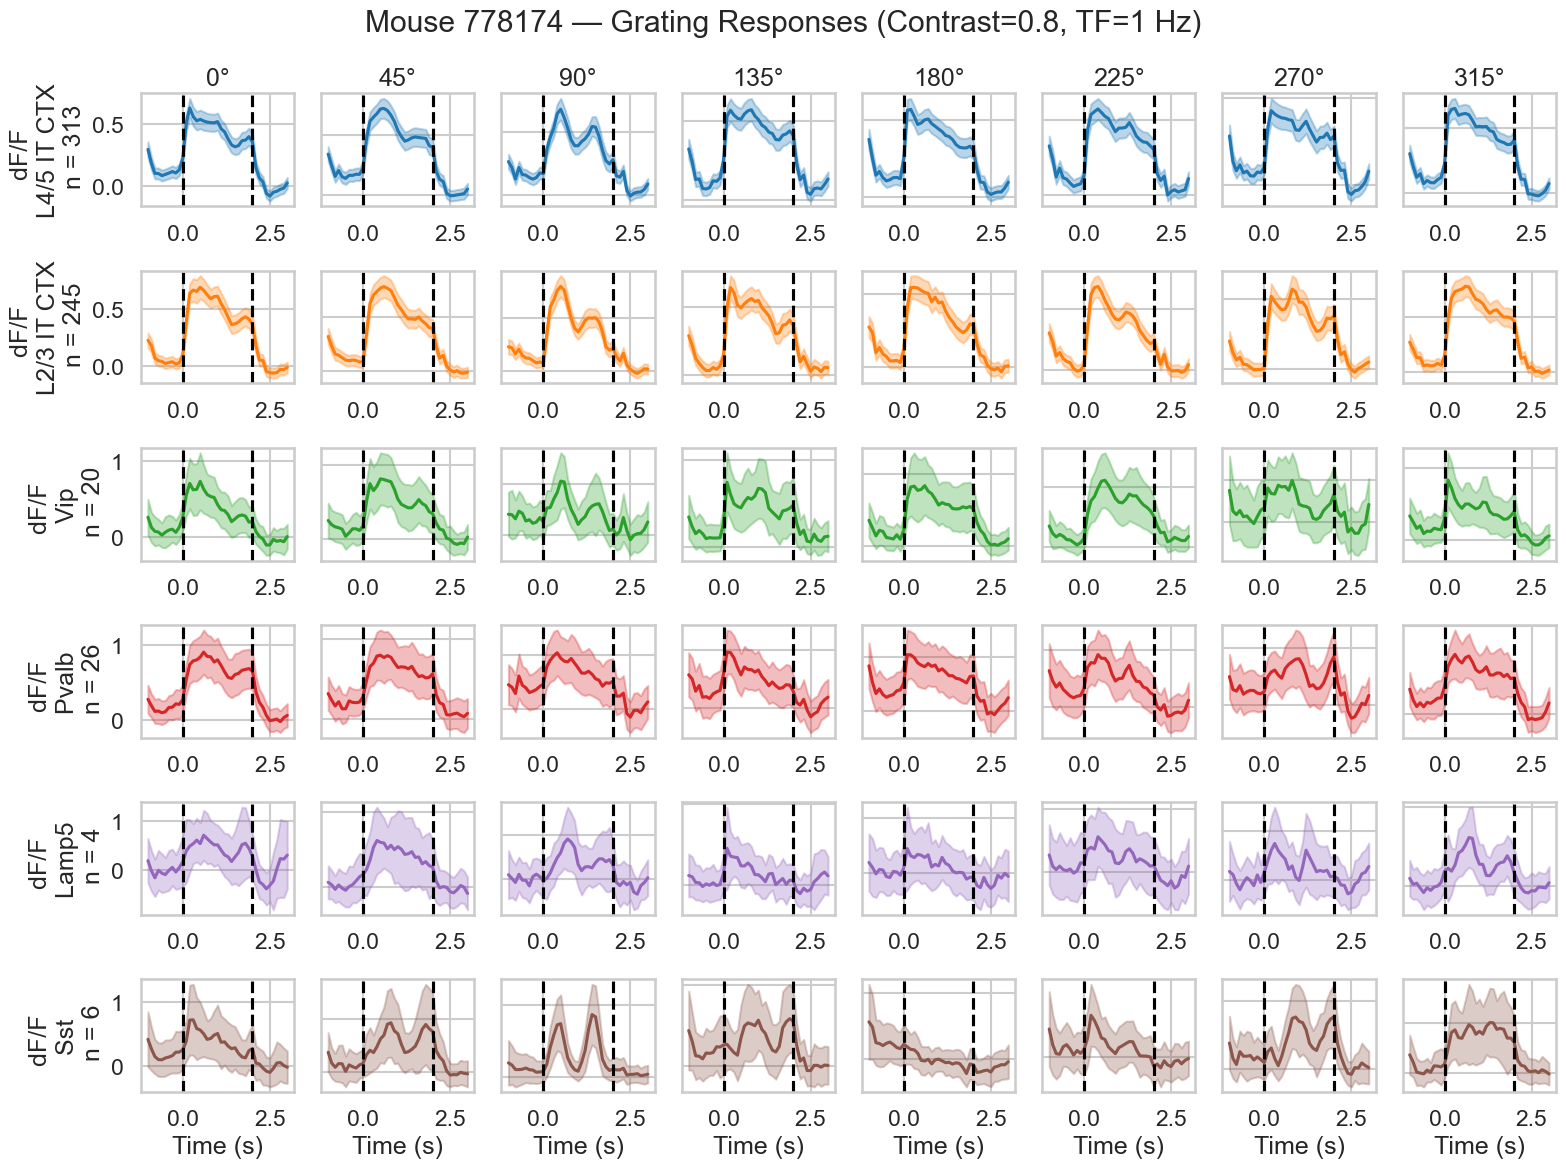

In [68]:
orientations = np.array([0, 45, 90, 135, 180, 225, 270, 315])
contrasts = np.array([0.05, 0.1, 0.2, 0.4, 0.8])
tfs = np.array([1, 2, 4, 8, 15])

target_contrast = 0.8
target_tf = 1

subclasses = morph_ct_df['subclass_name'].unique()

fig, axs = plt.subplots(len(subclasses), len(orientations), figsize=(len(orientations) * 2, len(subclasses) * 2))
for sc in subclasses:
    mask_sc = morph_ct_df['subclass_name'] == sc
    for i, ori in enumerate(orientations):
        mask_ori = trial_info['orientation'] == ori
        mask_contrast = trial_info['contrast'] == target_contrast
        mask_tf = trial_info['temporal_frequency'] == target_tf
        mask_trials = mask_ori & mask_contrast & mask_tf
        mean_response = np.nanmean(dff_normalized[mask_trials][:, :, mask_sc], axis=(0, 2))
        sd_response = np.nanstd(dff_normalized[mask_trials][:, :, mask_sc], axis=(0, 2)) / np.sqrt(mask_sc.sum())
        ax = axs[subclasses.tolist().index(sc), i]
        ax.plot(time_rel, mean_response, label=f'{sc} — {ori}°',color=sns.color_palette()[subclasses.tolist().index(sc)])
        ax.fill_between(time_rel, mean_response - sd_response, mean_response + sd_response, alpha=0.3, color=sns.color_palette()[subclasses.tolist().index(sc)])
        if sc == subclasses[0]:
            ax.set_title(f'{ori}°')
        if subclasses.tolist().index(sc) == len(subclasses) - 1:
            ax.set_xlabel('Time (s)')
        if i == 0:
            ax.set_ylabel(f'dF/F \n {" ".join(sc.split( )[1:-1])} \n n = {mask_sc.sum()}')
        else:
            ax.set_yticklabels([])
        ax.axvline(0, color='k', linestyle='--')
        ax.axvline(2, color='k', linestyle='--')
        
plt.suptitle(f'Mouse {mouse_id} — Grating Responses (Contrast={target_contrast}, TF={target_tf} Hz)')
plt.tight_layout()
plt.show()
        

## 7. Trial Info

In [ ]:
ti = gs['trial_info']
print('Trial info fields:', list(ti.keys()))

trial_info = pd.DataFrame({k: ti[k][:] for k in ti.keys()})
print(f'\n{len(trial_info)} trials, {trial_info["gray_screen"].sum()} are gray-screen')
trial_info.head()

In [ ]:
# Filter to actual grating trials
grating_trials = trial_info[~trial_info['gray_screen']]
print(f'{len(grating_trials)} grating trials')
print('Contrasts:', sorted(grating_trials['contrast'].unique()))
print('Orientations:', sorted(grating_trials['orientation'].unique()))
print('Temporal freqs:', sorted(grating_trials['temporal_frequency'].unique()))

## 8. Example: Plot Mean ΔF/F Trace for One Cell

In [ ]:
# Load all dff for GratingStim — this may take a moment
dff_all = gs['dff'][:]

# Pick a random cell and compute trial-average trace
cell_idx = 0
valid = ~trial_info['gray_screen'].values
mean_trace = np.nanmean(dff_all[valid, :, cell_idx], axis=0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(time_rel, mean_trace, 'k-', lw=1.5)
ax.axvline(0, color='r', ls='--', alpha=0.5, label='stim onset')
ax.axvline(2.0, color='b', ls='--', alpha=0.5, label='stim offset')
ax.set_xlabel('Time (s)'); ax.set_ylabel('ΔF/F')
ax.set_title(f'Cell {unique_ids[cell_idx]} — Trial-averaged trace')
ax.legend()
plt.tight_layout()
plt.show()

## 9. Tuning Properties

In [ ]:
tp = sess['tuning_properties']
print('Tuning arrays:', list(tp.keys()))

tuning_df = pd.DataFrame({k: tp[k][:] for k in tp.keys()})
tuning_df['unique_id'] = unique_ids
tuning_df['subclass'] = ct_df['subclass_name'].values

print(f'\nOSI: median={tuning_df["OSI"].median():.3f}')
print(f'DSI: median={tuning_df["DSI"].median():.3f}')
tuning_df[['unique_id', 'subclass', 'OSI', 'DSI', 'pref_ori', 'C50', 'pref_TF']].head(10)

In [ ]:
# OSI distribution by subclass
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=tuning_df, x='subclass', y='OSI', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_title(f'Mouse {mouse_id} — OSI by Subclass ({session})')
plt.tight_layout()
plt.show()

## 10. GLM Results

In [ ]:
glm = sess['glm']
print('GLM groups:', list(glm.keys()))

# Scores
score_grp = glm['score']
score_keys = list(score_grp.keys())
print(f'\nScore arrays ({len(score_keys)} total): {score_keys[:8]}...')

score_total = score_grp['score_total'][:]
print(f'score_total — shape: {score_total.shape}, median R²: {np.nanmedian(score_total):.3f}')

In [ ]:
# Coefficients
coef_grp = glm['coef']
coef_keys = list(coef_grp.keys())
print(f'Coefficient arrays ({len(coef_keys)} total)')
print('First 10:', coef_keys[:10])

## 11. Catch & GreyScreen Stimuli

In [ ]:
for stim_name in ['Catch', 'GreyScreen']:
    if stim_name in sadff:
        stim = sadff[stim_name]
        print(f'\n{stim_name}:')
        print(f'  dff shape:     {stim["dff"].shape}')
        print(f'  time_relative: {stim["time_relative"][:][0]:.1f} to {stim["time_relative"][:][-1]:.1f} s')
    else:
        print(f'{stim_name} not found in this session')

## 12. Using the Helper Functions

The `functions/data_loading.py` module provides two high-level loaders that return ready-to-use data structures.

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from functions.data_loading import load_mouse_zarr, load_zarr_10hz

# Trial-averaged data (adata-like namespace)
adata = load_mouse_zarr(mouse_id, zarr_dir=str(MULTIMODAL))
print(f'adata.X shape: {adata.X.shape}  (n_cells × total_grating_trials across 3 sessions)')
print(f'adata.obs columns: {list(adata.obs.columns[:8])}...')
print(f'adata.var columns: {list(adata.var.columns)}')

In [ ]:
# 10 Hz trial-resolved data for a single session
pk = load_zarr_10hz(mouse_id, session='session_1', zarr_dir=str(MULTIMODAL))
print(f'dff shape:       {pk["dff"].shape}     (n_trials, n_timepoints, n_cells)')
print(f'running shape:   {pk["running"].shape}')
print(f'time_rel:        {pk["time_rel"][[0, -1]]}')
print(f'trial_info cols: {list(pk["trial_info"].columns)}')